# 1 线性回归的从零开始实现

## 包括数据流水线 模型 损失函数 和小批量随机梯度下降优化器

In [5]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 根据带有噪声的线性模型构造一个人造数据集。y=Xw+b+？

In [10]:
def synthetic_data(w,b,num_examples):
    """生成y=Xw+b+噪声。"""
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))

true_w=torch.tensor([2,-3.4])
true_b=4.2
features, labels=synthetic_data(true_w,true_b,1000)

### features中的每一行都包含一个二维数据样本，labels中的每一行都包含一维标签值（一个标量）

In [11]:
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([-1.3710,  1.5495]) 
label: tensor([-3.8067])


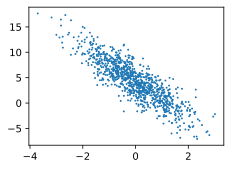

In [14]:
d2l.set_figsize()
d2l.plt.scatter(features[:,(1)].detach().numpy(),
                 labels.detach().numpy(),1)

### 定义一个data_iter函数，该函数接收批量大小 特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

In [20]:
def data_iter(batch_size, features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    # 这些数为随机读取的 
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(
            indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size=10

for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.5527, -0.0047],
        [-2.3316,  0.3219],
        [ 1.4365,  2.0107],
        [-0.4974,  0.7329],
        [-2.1989, -0.1965],
        [-0.6761, -0.9855],
        [ 0.0296, -1.2829],
        [ 0.8913,  1.2607],
        [-1.4723,  0.4740],
        [-2.0950,  0.4063]]) 
 tensor([[ 5.3246],
        [-1.5783],
        [ 0.2261],
        [ 0.7174],
        [ 0.4737],
        [ 6.1971],
        [ 8.6200],
        [ 1.6883],
        [-0.3786],
        [-1.3790]])


### 定义 初始化模型参数|

In [21]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

### 定义模型

In [22]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

### 定义损失函数

In [23]:
def squared_loss(y_hat,y):
    '''均方损失'''
    return (y_hat-y.reshape(y_hat.shape))**2/2

### 定义优化算法

In [24]:
def sgd(params,lr,batch_size):
    '''小批量随机梯度下降'''
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

### 训练过程

In [27]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # 前向传播：计算当前批次的损失
        l = loss(net(X, w, b), y)

        # 反向传播：计算 w.grad 和 b.grad
        l.sum().backward()

        # 根据梯度更新 w、b，并清空梯度
        sgd([w, b], lr, batch_size)

    # 一个 epoch 全部训练完成后，再计算整体训练损失
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000050
epoch 2, loss 0.000051
epoch 3, loss 0.000051


### 比较真实参数和通过训练学到的参数来评估训练的成功程度

In [28]:
print(f'w的估计误差：{true_w-w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b-b}')

w的估计误差：tensor([-3.7599e-04, -1.2398e-05], grad_fn=<SubBackward0>)
b的估计误差：tensor([8.1062e-05], grad_fn=<RsubBackward1>)
